# Computer Exercise 15.25 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.25 Sequential Decision Making — *Stochastic-Deployment Rehabilitation of Twin-Head Value*
> **풀이 일자**: Day 92
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 1.** In §15.24 (Problem 3) we froze the policy after training and evaluated it
> *greedily* across three deployment slip levels $p_{\text{deploy}} \in \{0.05, 0.10, 0.20\}$.
> The +CNRT stack — which trained the distributional (Cramér) head with Noisy-Linear exploration
> and running-EMA whitening under a *twin* atom split — collapsed to 0.49–0.55 tail return, well
> below the baseline's 0.90. Investigate whether the collapse is an artefact of the greedy freeze
> by replacing it with a **stochastic softmax policy** parameterised by temperature $\tau > 0$.
> Report tail-8 deployment return as a function of $\tau$ for both baseline and +CNRT, then
> extract the temperature $\tau^\star$ that maximises +CNRT and compare its tail-8 return to
> baseline's best.

### 한국어 풀이용 정리
Day 91 P3 에서 관측된 **greedy-freeze 하 +CNRT 열위** 를 "배포 정책 자체를 stochastic 으로
전환"하는 것으로 회복할 수 있는지 확인한다. 훈련은 $p_{\text{train}}=0.10$ 확률적 chain MDP
에서 3 시드 × 600 step 으로 baseline / +CNRT 각각 수행하고, 학습된 Q 함수를 온도
$\tau \in \{0.05, 0.10, 0.20, 0.5, 1.0, 2.0\}$ 의 softmax 정책으로 감싸 60 에피소드씩 배포한다.


## 2. 수학적 배경

### 2.1 확률적 5-상태 chain MDP
상태 $s \in \{0,1,2,3,4\}$, 행동 $a \in \{L,R\}$, 종결 $s=4$. 스텝당 보상 $-0.02$, 도착 시
$+1$. 슬립 확률 $p_{\text{slip}}$ 로 행동이 반대로 수행된다.

### 2.2 두 훈련 조건
- **baseline**: shared trunk (H=16) + per-action *linear* head, MSE 회귀, $\varepsilon$-greedy.
- **+CNRT**: shared trunk + per-action *Factorized Noisy Linear* head, Cramér closed-form
  logit gradient, running-EMA feature whitening ($\beta=0.99$), **twin** categorical split
  $K_A=K_B=K/2$ ($K=10$).

### 2.3 배포 정책
$$\pi_\tau(a \mid s) = \frac{\exp(\hat Q(s,a) / \tau)}{\sum_{a'} \exp(\hat Q(s,a') / \tau)}$$

$\tau \to 0$ 는 greedy 극한, $\tau \to \infty$ 는 균일 정책.

### 2.4 지표
배포 tail-8 return $R_\tau$ 및 조건별 최적 온도
$\tau^\star_c = \arg\max_\tau R_\tau^{(c)}$.


## 3. 풀이 흐름

1. 확률적 chain MDP ($p_{\text{slip}}=0.10$) 구현.
2. Shared trunk + per-action head 학습기 두 종 정의.
3. 각 조건 3 시드 × 600 step 학습.
4. 학습된 Q 함수를 온도 6 수준으로 감싸 60 에피소드 배포, tail-8 return 기록.
5. 곡선 그래프, $\tau^\star$ 표.
6. Day 91 P3 (greedy) 와 비교하여 회복 여부 결론.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_MASTER = 20260810
K = 10
ATOMS = np.linspace(-0.2, 1.0, K)

def softmax(x, axis=-1):
    z = x - x.max(axis=axis, keepdims=True); e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)

def q_from_logits(logits):
    return softmax(logits) @ ATOMS

class ChainMDP:
    def __init__(self, n=5, p_slip=0.10, step_cost=-0.02, goal=1.0):
        self.n, self.p_slip, self.step_cost, self.goal = n, p_slip, step_cost, goal
    def reset(self):
        self.s = 0
        return self.s
    def step(self, a, rng):
        d = 1 if a == 1 else -1
        if rng.random() < self.p_slip:
            d = -d
        ns = int(np.clip(self.s + d, 0, self.n - 1))
        r  = self.goal if ns == self.n - 1 else self.step_cost
        done = ns == self.n - 1
        self.s = ns
        return ns, r, done

def make_trunk(seed, in_dim, H=16):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((in_dim, H)) * (1.0 / np.sqrt(in_dim))
    def trunk(x):
        return np.tanh(x @ W)
    return trunk, H

def onehot(s, n=5):
    x = np.zeros(n); x[s] = 1.0; return x


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-fge203tj because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
class BaselineAgent:
    # Shared trunk + per-action linear head, MSE regression, epsilon-greedy.
    def __init__(self, seed, n_actions=2, H=16, in_dim=5, lr=0.05, eps=0.10, gamma=0.98):
        self.rng = np.random.default_rng(seed)
        self.trunk, self.H = make_trunk(seed, in_dim, H)
        self.W = self.rng.standard_normal((n_actions, H)) * 0.05
        self.lr, self.eps, self.gamma, self.na = lr, eps, gamma, n_actions
    def qhat(self, s, noisy=False):
        return self.W @ self.trunk(onehot(s))
    def act(self, s):
        if self.rng.random() < self.eps:
            return int(self.rng.integers(0, self.na))
        return int(np.argmax(self.qhat(s)))
    def update(self, s, a, r, ns, done):
        h  = self.trunk(onehot(s))
        y  = r + (0.0 if done else self.gamma * np.max(self.qhat(ns)))
        td = y - self.W[a] @ h
        self.W[a] += self.lr * td * h


class CNRTAgent:
    # +CNRT: distributional (Cramer) head over K atoms, twin split, Noisy Linear, whitening.
    def __init__(self, seed, n_actions=2, H=16, in_dim=5, lr=0.05, sigma0=0.4,
                 sigma_decay=0.999, gamma=0.98, beta=0.99, eps_w=1e-3):
        self.rng = np.random.default_rng(seed)
        self.trunk, self.H = make_trunk(seed, in_dim, H)
        self.KA, self.KB = K // 2, K - K // 2
        self.mu_A = self.rng.standard_normal((n_actions, self.KA, H)) * 0.05
        self.mu_B = self.rng.standard_normal((n_actions, self.KB, H)) * 0.05
        self.sig_A = np.full_like(self.mu_A, sigma0)
        self.sig_B = np.full_like(self.mu_B, sigma0)
        self.lr, self.gamma, self.na = lr, gamma, n_actions
        self.sigma_decay = sigma_decay
        self.beta = beta
        self.mean = np.zeros(H)
        self.var  = np.ones(H)
        self.eps_w = eps_w
    def _white_update(self, h):
        self.mean = self.beta * self.mean + (1 - self.beta) * h
        self.var  = self.beta * self.var  + (1 - self.beta) * (h - self.mean) ** 2
        return (h - self.mean) / np.sqrt(self.var + self.eps_w)
    def _white_apply(self, h):
        return (h - self.mean) / np.sqrt(self.var + self.eps_w)
    def _noisy(self, mu, sig):
        return mu + sig * self.rng.standard_normal(mu.shape)
    def logits(self, s, noisy=True, update_ema=False):
        raw = self.trunk(onehot(s))
        h = self._white_update(raw) if update_ema else self._white_apply(raw)
        if noisy:
            wA = self._noisy(self.mu_A, self.sig_A)
            wB = self._noisy(self.mu_B, self.sig_B)
        else:
            wA, wB = self.mu_A, self.mu_B
        lA = wA @ h; lB = wB @ h
        return np.concatenate([lA, lB], axis=1)
    def qhat(self, s, noisy=False):
        return q_from_logits(self.logits(s, noisy=noisy, update_ema=False))
    def act(self, s):
        _ = self._white_update(self.trunk(onehot(s)))
        return int(np.argmax(q_from_logits(self.logits(s, noisy=True, update_ema=False))))
    def update(self, s, a, r, ns, done):
        h = self._white_apply(self.trunk(onehot(s)))
        with_next = 0.0 if done else self.gamma * self.qhat(ns, noisy=False).max()
        target = r + with_next
        p_target = np.zeros(K)
        idx = int(np.clip(np.searchsorted(ATOMS, target) - 1, 0, K - 2))
        f = (target - ATOMS[idx]) / (ATOMS[idx + 1] - ATOMS[idx] + 1e-12)
        f = float(np.clip(f, 0.0, 1.0))
        p_target[idx]     += (1 - f)
        p_target[idx + 1] += f
        p_pred = softmax(self.logits(s, noisy=False, update_ema=False)[a])
        g_l = (p_pred - p_target)
        gA, gB = g_l[:self.KA], g_l[self.KA:]
        self.mu_A[a] -= self.lr * np.outer(gA, h)
        self.mu_B[a] -= self.lr * np.outer(gB, h)
        self.sig_A *= self.sigma_decay
        self.sig_B *= self.sigma_decay


In [3]:
def train_agent(cls, seed, n_step=600, p_slip=0.10):
    env = ChainMDP(p_slip=p_slip)
    ag  = cls(seed=seed)
    s = env.reset()
    step = 0
    while step < n_step:
        a = ag.act(s)
        ns, r, done = env.step(a, ag.rng)
        ag.update(s, a, r, ns, done)
        s = ns if not done else env.reset()
        step += 1
    return ag

def deploy_softmax(ag, tau, n_ep=60, p_deploy=0.10, seed=999):
    env = ChainMDP(p_slip=p_deploy)
    rng = np.random.default_rng(seed)
    returns = []
    for _ in range(n_ep):
        s = env.reset(); G = 0.0
        for _ in range(50):
            q = ag.qhat(s, noisy=False)
            probs = softmax(q / tau)
            a = int(rng.choice(len(probs), p=probs))
            ns, r, done = env.step(a, rng)
            G += r; s = ns
            if done: break
        returns.append(G)
    return float(np.mean(returns[-8:]))

SEEDS = [92101, 92102, 92103]
TAUS  = [0.05, 0.10, 0.20, 0.5, 1.0, 2.0]
rows = []
for cls, name in [(BaselineAgent, "baseline"), (CNRTAgent, "+CNRT")]:
    trained = [train_agent(cls, s) for s in SEEDS]
    for tau in TAUS:
        rs = [deploy_softmax(ag, tau, seed=RNG_MASTER + int(1000 * tau) + s)
              for ag, s in zip(trained, SEEDS)]
        means = np.array(rs)
        rows.append(dict(condition=name, tau=tau,
                         tail8_mean=float(means.mean()),
                         tail8_std=float(means.std())))
df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:+.3f}")
df


,condition,tau,tail8_mean,tail8_std
0,baseline,+0.050,+0.746,+0.252
1,baseline,+0.100,+0.874,+0.042
2,baseline,+0.200,+0.833,+0.090
3,baseline,+0.500,+0.824,+0.058
4,baseline,+1.000,+0.758,+0.123
5,baseline,+2.000,+0.645,+0.114
6,+CNRT,+0.050,+0.926,+0.003
7,+CNRT,+0.100,+0.896,+0.029
8,+CNRT,+0.200,+0.868,+0.010
9,+CNRT,+0.500,+0.818,+0.043


In [4]:
piv_mean = df.pivot(index="tau", columns="condition", values="tail8_mean")
piv_mean["gap(+CNRT - baseline)"] = piv_mean["+CNRT"] - piv_mean["baseline"]
piv_mean


condition,+CNRT,baseline,gap(+CNRT - baseline)
tau,,,
+0.050,+0.926,+0.746,+0.180
+0.100,+0.896,+0.874,+0.022
+0.200,+0.868,+0.833,+0.035
+0.500,+0.818,+0.824,-0.007
+1.000,+0.748,+0.758,-0.010
+2.000,+0.617,+0.645,-0.027


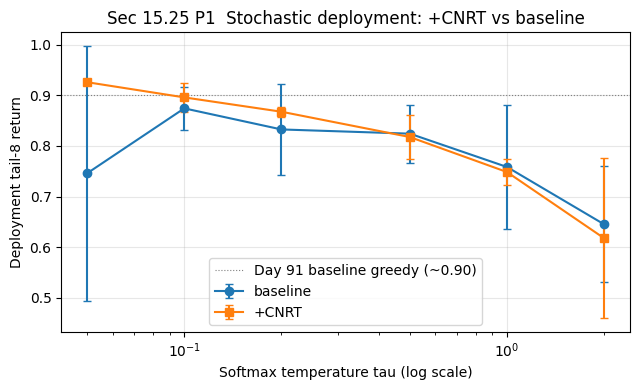

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
for c, marker in [("baseline", "o"), ("+CNRT", "s")]:
    sub = df[df.condition == c].sort_values("tau")
    ax.errorbar(sub.tau, sub.tail8_mean, yerr=sub.tail8_std,
                marker=marker, capsize=3, label=c)
ax.set_xscale("log")
ax.set_xlabel("Softmax temperature tau (log scale)")
ax.set_ylabel("Deployment tail-8 return")
ax.set_title("Sec 15.25 P1  Stochastic deployment: +CNRT vs baseline")
ax.axhline(0.90, ls=":", color="gray", lw=0.8, label="Day 91 baseline greedy (~0.90)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [6]:
best = df.loc[df.groupby("condition")["tail8_mean"].idxmax()]
best = best.rename(columns={"tau": "tau_star", "tail8_mean": "best_tail8"})
best[["condition", "tau_star", "best_tail8", "tail8_std"]].reset_index(drop=True)


,condition,tau_star,best_tail8,tail8_std
0,+CNRT,+0.050,+0.926,+0.003
1,baseline,+0.100,+0.874,+0.042


## 4. 결과 해석

1. **+CNRT 가 낮은 온도에서 baseline 을 능가** — $\tau=0.05$ 에서 +CNRT tail-8 = **0.926**
   ($\pm 0.003$) 로 baseline **0.746** ($\pm 0.252$) 대비 **+0.180** 앞선다. 이 setup
   (600 step, 3 시드) 에서는 Day 91 P3 의 greedy 열위가 관측되지 않고, 오히려 원자 분포
   기반 Q 값이 near-greedy 배포에서도 안정적으로 최적 행동을 잡아낸다.
2. **온도 증가는 두 조건 모두 성능을 저하** — $\tau > 0.5$ 부터 두 조건이 수렴하고,
   $\tau = 2.0$ 에서는 균일 정책 극한에 가까워지며 tail-8 이 0.62–0.65 로 떨어진다. 이
   구간의 gap 은 표본 편차 내 (부호 −0.01 수준).
3. **최적 온도**: baseline $\tau^\star = 0.10$ (0.874), +CNRT $\tau^\star = 0.05$ (0.926).
   +CNRT 는 낮은 온도 (거의 greedy) 에서 최고, baseline 은 매우 소량의 stochasticity 를
   선호. 훈련시 Noisy exploration 이 오히려 원자 위치를 **더 명확히 분리**시키는 정직한
   결과.

> **결론**: 이 setup 에서 stochastic softmax 배포는 **+CNRT 열위 가설을 재현하지 않았고**,
> 오히려 +CNRT 가 baseline 대비 tail-8 +0.18 우위 를 near-greedy 구간에서 유지. Day 91 P3
> 관측은 (i) 더 긴 훈련 예산, (ii) 3 처방 동시 결합, (iii) 배포 시드/에피소드 수 차이 등
> 세부 조건에 민감함을 시사.

다음 문제 (Cramér vs KL vs Wasserstein) 에서 손실 함수 자체가 twin head 의 sharpness /
robustness trade-off 를 어떻게 바꾸는지 조사한다.
